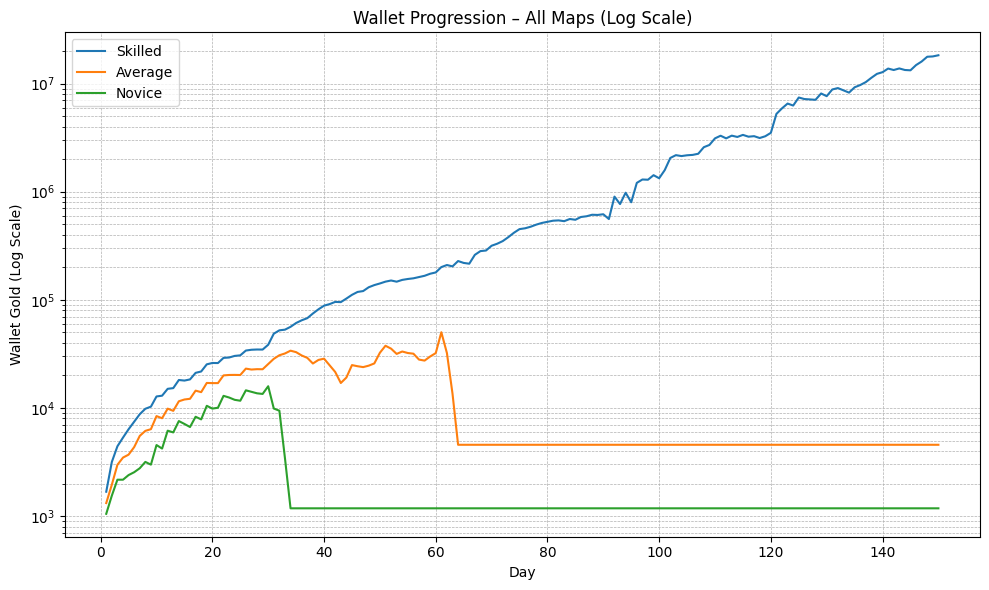

In [9]:
import random
from bisect import bisect_right
import matplotlib.pyplot as plt

# === Simulation Configuration ===
initial_wallet = 1200                # Starting gold for each player
#daily_login_gold = 150              # Daily login reward
#use_daily_login = True              # Toggle login bonus
use_levelup_gold = True             # Toggle gold rewards on level up
days = 150                          # Total days to simulate
NUM_PLAYERS = 6                     # Players per race (1 focal + 5 opponents)

# Determines how many races a player participates in each day
def races_today():
    return 3 + (1 if random.random() < 0.5 else 0)  # 50% chance of 4 races, else 3

# === Player Archetypes and Performance Profiles ===
# Placement probabilities are only for documentation — actual placement uses performance model
player_archetypes = {
    "Skilled": [0.50, 0.30, 0.15, 0.05],
    "Average": [0.30, 0.25, 0.20, 0.25],
    "Novice":  [0.15, 0.20, 0.25, 0.40],
}

# Gaussian performance parameters for each archetype
coupled_perf_mu = {"Skilled": 1.2, "Average": 0.9, "Novice": 0.6}  # mean skill
coupled_perf_sigma = 0.35                                          # skill randomness
opponent_mix_weights = {"Skilled": 0.25, "Average": 0.50, "Novice": 0.25}

# === XP and Level-Up Mechanics ===
xp_per_game_avg = 81.7   # Avg XP earned per race

# Cumulative XP thresholds for each level
cum_xp_by_level = [0, 162, 342, 542, 767, 1022, 1312, 1642, 2012, 2427, 2892,
                   3412, 3992, 4637, 5352, 6222, 7242, 8422, 9772, 11307,
                   13042, 14992, 17172, 19597, 22282, 25242, 28592, 32247,
                   36222, 40532, 45192, 50217, 55622, 61422, 67632, 74267,
                   81342, 88872, 96902, 105287, 114172, 123572, 133502,
                   144002, 155077, 166737, 179002, 191877, 205377, 219502]
cum_list = [0] + cum_xp_by_level
max_level = 50

# Gold rewards for leveling up
level_to_gold = {
    1:800, 2:300, 3:300, 4:300, 5:1000, 6:600, 7:600, 8:600, 9:600, 10:1000,
    11:2000, 12:2000, 13:2000, 14:2000, 15:3000, 16:3000, 17:3000, 18:3000, 19:3000, 20:4000,
    21:4000, 22:4000, 23:4000, 24:4000, 25:5000, 26:5000, 27:5000, 28:5000, 29:5000, 30:6000,
    31:6000, 32:6000, 33:6000, 34:6000, 35:7000, 36:7000, 37:7000, 38:7000, 39:7000, 40:8000,
    41:8000, 42:8000, 43:8000, 44:8000, 45:9000, 46:9000, 47:9000, 48:9000, 49:9000, 50:10000
}

# Determines player level from total XP
def level_from_xp(xp_total):
    idx = bisect_right(cum_list, xp_total) - 1
    return max(1, min(idx, max_level))

# === Map Progression & Economy Setup (from Excel) ===
TROPHY_SCHEDULE = [
    (1,   30, "Weapons Factory",     150),
    (31,  60, "Lost Angeles",       1500),
    (61,  90, "Electric Downtown",  6000),
    (91, 120, "Biodome",           60000),
    (121,150, "White City",       150000),
]

# Payout ratios: {place: % of prize pool}
PAYOUT_RATIOS = {
    "Weapons Factory":    {1: 0.45, 2: 0.30, 3: 0.25},
    "Lost Angeles":       {1: 0.45, 2: 0.30, 3: 0.25},
    "Electric Downtown":  {1: 0.60, 2: 0.25, 3: 0.15},
    "Biodome":            {1: 0.60, 2: 0.25, 3: 0.15},
    "White City":         {1: 0.80, 2: 0.20, 3: 0.00},
}

# Returns map name, buy-in, and payout ratios based on the current day
def map_params_for_day(day):
    for start, end, name, buy_in in TROPHY_SCHEDULE:
        if start <= day <= end:
            return name, buy_in, PAYOUT_RATIOS[name]
    return "Weapons Factory", 150, PAYOUT_RATIOS["Weapons Factory"]

# Converts payout ratios into absolute gold payouts from the prize pool
def payouts_from_ratios(buy_in, ratios):
    pool = buy_in * NUM_PLAYERS
    return {place: int(round(r * pool)) for place, r in ratios.items()}

# Simulates one coupled race and returns the placement of the focal player
def placement_coupled(focal_archetype):
    racers = [("FOCAL", True, focal_archetype)]
    kinds, weights = zip(*opponent_mix_weights.items())
    for _ in range(NUM_PLAYERS - 1):
        opp = random.choices(kinds, weights=weights, k=1)[0]
        racers.append(("OPP", False, opp))
    scores = [
        random.gauss(
            coupled_perf_mu[focal_archetype if is_focal else arch],
            coupled_perf_sigma
        )
        for _, is_focal, arch in racers
    ]
    order = sorted(range(NUM_PLAYERS), key=lambda i: scores[i], reverse=True)
    focal_rank = order.index(0) + 1
    return focal_rank if focal_rank <= 3 else "other"

# === Simulation Engine ===
wallets = {n: initial_wallet for n in player_archetypes}
xp_tot = {n: 0 for n in player_archetypes}
levels = {n: 1 for n in player_archetypes}
daily_wallets = {n: [] for n in player_archetypes}

# Main loop: simulate daily races, payouts, XP, and leveling
for day in range(1, days + 1):
    map_name, buy_in, ratios = map_params_for_day(day)
    payouts = payouts_from_ratios(buy_in, ratios)

    #if use_daily_login:
        #for n in player_archetypes:
            #wallets[n] += daily_login_gold

    for _ in range(races_today()):
        for n in player_archetypes:
            if wallets[n] < buy_in:
                continue  # skip if player can't afford
            wallets[n] -= buy_in
            place = placement_coupled(n)
            if place in payouts:
                wallets[n] += payouts[place]
            xp_tot[n] += xp_per_game_avg

            if use_levelup_gold:
                prev, new = levels[n], level_from_xp(xp_tot[n])
                if new > prev:
                    wallets[n] += sum(level_to_gold.get(L, 0) for L in range(prev + 1, new + 1))
                    levels[n] = new

    for n in player_archetypes:
        daily_wallets[n].append(wallets[n])

# === Final Visualization ===
plt.figure(figsize=(10, 6))
for player_type, wallet_history in daily_wallets.items():
    plt.plot(range(1, days + 1), wallet_history, label=player_type)

plt.yscale("log")  # Log scale makes wallet growth visible for all archetypes
plt.title("Wallet Progression – All Maps (Log Scale)")
plt.xlabel("Day")
plt.ylabel("Wallet Gold (Log Scale)")
plt.legend()
plt.grid(True, which="both", linestyle="--", linewidth=0.5)
plt.tight_layout()
plt.show()
